# Laboratorio 04 Clasificación Multiclase One-vs-All
## Dataset: CICIDS2017 — Cleaned & Preprocessed

### Dataset
El dataset **CICIDS2017: Cleaned & Preprocessed** obtenido de Kaggle contiene registros de tráfico de red con las siguientes características:
- **53 características numéricas** (n ≥ 40 ✓): duración del flujo, longitud de paquetes, puertos, flags TCP, etc.
- **Más de 2 millones de ejemplos** (m ≥ 50,000 ✓)
- **Columna objetivo `Label`**: tráfico BENIGN o distintos tipos de ataques (DoS, DDoS, PortScan, etc.)

URL del dataset:
[https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed](https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed).

## 1. Importación de Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Carga y Exploración del Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/cicids2017_cleaned.csv')
df.head()

Mounted at /content/drive


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [3]:
# Columnas disponibles
print(f'Total de columnas: {len(df.columns)}')
print('\nColumnas:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:3d}. {col}')

Total de columnas: 53

Columnas:
    1. Destination Port
    2. Flow Duration
    3. Total Fwd Packets
    4. Total Length of Fwd Packets
    5. Fwd Packet Length Max
    6. Fwd Packet Length Min
    7. Fwd Packet Length Mean
    8. Fwd Packet Length Std
    9. Bwd Packet Length Max
   10. Bwd Packet Length Min
   11. Bwd Packet Length Mean
   12. Bwd Packet Length Std
   13. Flow Bytes/s
   14. Flow Packets/s
   15. Flow IAT Mean
   16. Flow IAT Std
   17. Flow IAT Max
   18. Flow IAT Min
   19. Fwd IAT Total
   20. Fwd IAT Mean
   21. Fwd IAT Std
   22. Fwd IAT Max
   23. Fwd IAT Min
   24. Bwd IAT Total
   25. Bwd IAT Mean
   26. Bwd IAT Std
   27. Bwd IAT Max
   28. Bwd IAT Min
   29. Fwd Header Length
   30. Bwd Header Length
   31. Fwd Packets/s
   32. Bwd Packets/s
   33. Min Packet Length
   34. Max Packet Length
   35. Packet Length Mean
   36. Packet Length Std
   37. Packet Length Variance
   38. FIN Flag Count
   39. PSH Flag Count
   40. ACK Flag Count
   41. Average Packe

In [4]:
# Distribución de la columna objetivo
COLUMNA_OBJETIVO = 'Attack Type'

conteo_original = df[COLUMNA_OBJETIVO].value_counts()
print(f"Distribución de '{COLUMNA_OBJETIVO}':")
print(conteo_original)
print(f'\nTotal de categorías: {len(conteo_original)}')

Distribución de 'Attack Type':
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

Total de categorías: 7


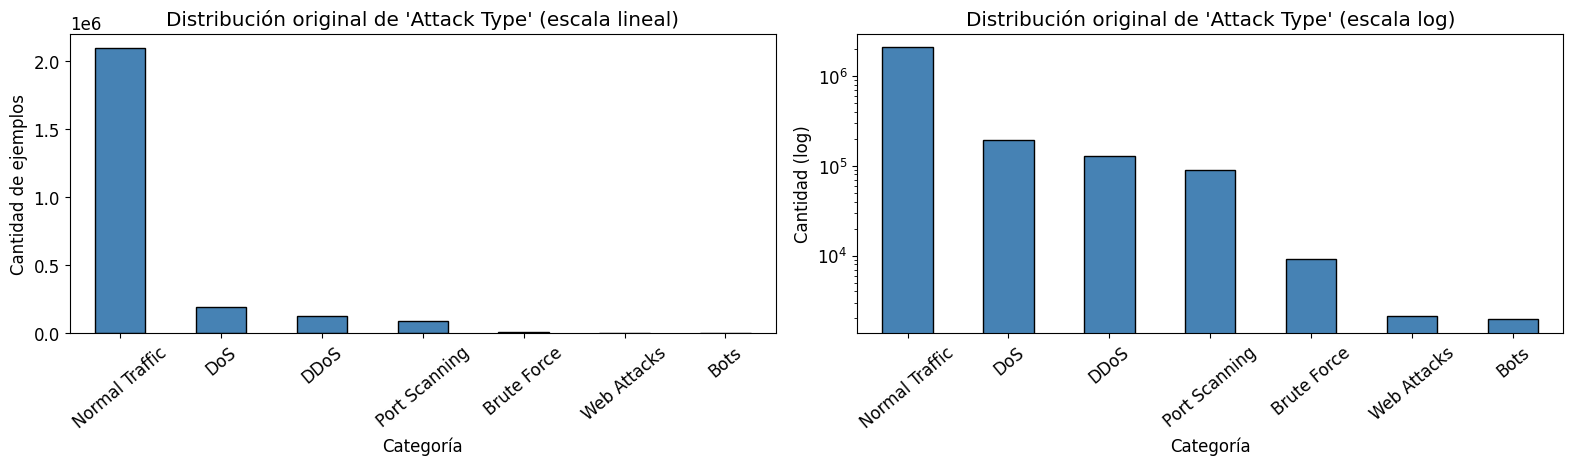

In [5]:
# Gráfica de distribución original (escala logarítmica por el fuerte desbalance)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

conteo_original.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Distribución original de 'Attack Type' (escala lineal)")
axes[0].set_xlabel('Categoría'); axes[0].set_ylabel('Cantidad de ejemplos')
axes[0].tick_params(axis='x', rotation=40)

conteo_original.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', logy=True)
axes[1].set_title("Distribución original de 'Attack Type' (escala log)")
axes[1].set_xlabel('Categoría'); axes[1].set_ylabel('Cantidad (log)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento con Pandas

### 3.1 Limpieza del Dataset

El dataset CICIDS2017 puede contener valores infinitos y NaN en algunas columnas como consecuencia del proceso de extracción de flujos. Aplicamos los siguientes pasos:
1. Reemplazar valores infinitos con NaN
2. Eliminar filas con NaN
3. Eliminar filas duplicadas

In [6]:
print(f'Forma inicial: {df.shape}')

# 1. Reemplazar infinitos
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Eliminar NaN
df.dropna(inplace=True)
print(f'Tras eliminar NaN/Inf:   {df.shape}')

# 3. Eliminar duplicados
df.drop_duplicates(inplace=True)
print(f'Tras eliminar duplicados: {df.shape}')

Forma inicial: (2520751, 53)
Tras eliminar NaN/Inf:   (2520751, 53)
Tras eliminar duplicados: (2520590, 53)


### 3.2 Agrupación en 3 Clases

Las 7 categorías del dataset se agrupan en **3 clases** según la naturaleza del tráfico:

| Clase | Nombre | Valores originales en `Attack Type` | Ejemplos |
|:---:|:---|:---|---:|
| **0** | Normal Traffic | `Normal Traffic` | 2,095,057 |
| **1** | DoS / DDoS | `DoS`, `DDoS` | 321,759 |
| **2** | Otros ataques | `Port Scanning`, `Brute Force`, `Web Attacks`, `Bots` | 103,935 |

El dataset tiene un fuerte desbalance: el tráfico normal representa el ~83% del total.

In [7]:
# Mapeo de valores exactos de la columna 'Attack Type' a clases numéricas
# Valores confirmados del dataset (ver distribución en Sección 2)
mapeo_clases = {
    # Clase 0 — Tráfico normal
    'Normal Traffic' : 0,

    # Clase 1 — Ataques de denegación de servicio
    'DoS'            : 1,
    'DDoS'           : 1,

    # Clase 2 — Otros tipos de ataque
    'Port Scanning'  : 2,
    'Brute Force'    : 2,
    'Web Attacks'    : 2,
    'Bots'           : 2,
}

mapa_nombres = {0: 'Normal Traffic', 1: 'DoS/DDoS', 2: 'Otros ataques'}
NUM_CLASES   = 3
COLORES      = ['royalblue', 'darkorange', 'forestgreen']

# Aplicar mapeo
df['y_encoded'] = df[COLUMNA_OBJETIVO].map(mapeo_clases)

# Verificar que todos los valores fueron mapeados
sin_mapeo = df['y_encoded'].isna().sum()
if sin_mapeo > 0:
    print(f'⚠  Filas sin mapeo: {sin_mapeo:,}')
    print(df.loc[df['y_encoded'].isna(), COLUMNA_OBJETIVO].value_counts())
else:
    print('✓ Todos los valores mapeados correctamente.')

df.dropna(subset=['y_encoded'], inplace=True)
df['y_encoded'] = df['y_encoded'].astype(int)

print('\nDistribución de clases agrupadas:')
for c, nom in mapa_nombres.items():
    n   = (df['y_encoded'] == c).sum()
    pct = n / len(df) * 100
    print(f'  Clase {c} - {nom:<18}: {n:>10,} ejemplos ({pct:5.2f}%)')
print(f'\n  Total: {len(df):,} ejemplos')

✓ Todos los valores mapeados correctamente.

Distribución de clases agrupadas:
  Clase 0 - Normal Traffic    :  2,094,896 ejemplos (83.11%)
  Clase 1 - DoS/DDoS          :    321,759 ejemplos (12.77%)
  Clase 2 - Otros ataques     :    103,935 ejemplos ( 4.12%)

  Total: 2,520,590 ejemplos


### 3.3 Selección de Características
Se seleccionan todas las columnas numéricas del dataset, excluyendo la variable objetivo y la codificación generada.

In [8]:
columnas_excluir = [COLUMNA_OBJETIVO, 'y_encoded']
columnas_X = [c for c in df.select_dtypes(include=[np.number]).columns
              if c not in columnas_excluir]

print(f'Características numéricas seleccionadas: {len(columnas_X)}  (n ≥ 40 ✓)')
print('\nLista de características:')
for i, col in enumerate(columnas_X):
    print(f'  {i+1:3d}. {col}')

Características numéricas seleccionadas: 52  (n ≥ 40 ✓)

Lista de características:
    1. Destination Port
    2. Flow Duration
    3. Total Fwd Packets
    4. Total Length of Fwd Packets
    5. Fwd Packet Length Max
    6. Fwd Packet Length Min
    7. Fwd Packet Length Mean
    8. Fwd Packet Length Std
    9. Bwd Packet Length Max
   10. Bwd Packet Length Min
   11. Bwd Packet Length Mean
   12. Bwd Packet Length Std
   13. Flow Bytes/s
   14. Flow Packets/s
   15. Flow IAT Mean
   16. Flow IAT Std
   17. Flow IAT Max
   18. Flow IAT Min
   19. Fwd IAT Total
   20. Fwd IAT Mean
   21. Fwd IAT Std
   22. Fwd IAT Max
   23. Fwd IAT Min
   24. Bwd IAT Total
   25. Bwd IAT Mean
   26. Bwd IAT Std
   27. Bwd IAT Max
   28. Bwd IAT Min
   29. Fwd Header Length
   30. Bwd Header Length
   31. Fwd Packets/s
   32. Bwd Packets/s
   33. Min Packet Length
   34. Max Packet Length
   35. Packet Length Mean
   36. Packet Length Std
   37. Packet Length Variance
   38. FIN Flag Count
   39. PSH Fla

### 3.4 Submuestreo Balanceado

El dataset está fuertemente desbalanceado:
- **Clase 0** (Normal Traffic): 2,095,057 ejemplos (~83%)
- **Clase 1** (DoS/DDoS):         321,759 ejemplos (~13%)
- **Clase 2** (Otros ataques):    103,935 ejemplos (~4%)

La clase minoritaria es **Otros ataques** con ~103,935 ejemplos. Para entrenar un clasificador imparcial, tomamos el mismo número de muestras de cada clase. El tope se fija en `TOPE_POR_CLASE` ejemplos (ajustable según la RAM disponible).

In [9]:
disponibles = {c: int((df['y_encoded'] == c).sum()) for c in range(NUM_CLASES)}
print('Ejemplos disponibles por clase antes del submuestreo:')
for c, n in disponibles.items():
    print(f'  Clase {c} ({mapa_nombres[c]:<18}): {n:>10,}')

# Tope máximo por clase (ajustar si hay poca RAM)
TOPE_POR_CLASE = 103935
n_por_clase = min(TOPE_POR_CLASE, min(disponibles.values()))
print(f'\nMuestras tomadas por clase: {n_por_clase:,}')

partes = [df[df['y_encoded'] == c].sample(n=n_por_clase, random_state=42)
          for c in range(NUM_CLASES)]

df_bal = pd.concat(partes, ignore_index=True)
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)  # Mezclar

print(f'\nDataset balanceado: {df_bal.shape[0]:,} ejemplos × {len(columnas_X)} características')
print(f'  m = {df_bal.shape[0]:,}  (≥ 50,000 ✓)')

# Confirmar distribución balanceada
print('\nDistribución tras el balanceo:')
for c, nom in mapa_nombres.items():
    n = (df_bal['y_encoded'] == c).sum()
    print(f'  Clase {c} ({nom:<18}): {n:,}')

Ejemplos disponibles por clase antes del submuestreo:
  Clase 0 (Normal Traffic    ):  2,094,896
  Clase 1 (DoS/DDoS          ):    321,759
  Clase 2 (Otros ataques     ):    103,935

Muestras tomadas por clase: 103,935

Dataset balanceado: 311,805 ejemplos × 52 características
  m = 311,805  (≥ 50,000 ✓)

Distribución tras el balanceo:
  Clase 0 (Normal Traffic    ): 103,935
  Clase 1 (DoS/DDoS          ): 103,935
  Clase 2 (Otros ataques     ): 103,935


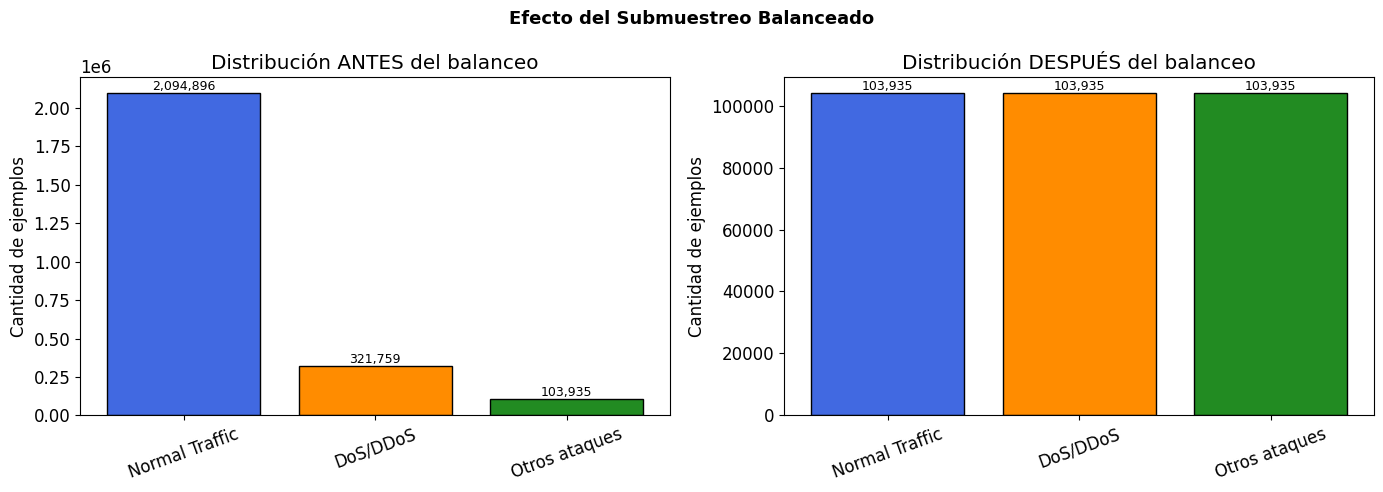

In [10]:
# Gráfica comparativa: distribución antes y después del balanceo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
valores_antes = [disponibles[c] for c in range(NUM_CLASES)]
axes[0].bar(range(NUM_CLASES), valores_antes,
            color=COLORES, edgecolor='black')
axes[0].set_xticks(range(NUM_CLASES))
axes[0].set_xticklabels([mapa_nombres[c] for c in range(NUM_CLASES)], rotation=20)
axes[0].set_title('Distribución ANTES del balanceo')
axes[0].set_ylabel('Cantidad de ejemplos')
for i, v in enumerate(valores_antes):
    axes[0].text(i, v + max(valores_antes)*0.01, f'{v:,}', ha='center', fontsize=9)

# Después
valores_despues = [n_por_clase] * NUM_CLASES
axes[1].bar(range(NUM_CLASES), valores_despues,
            color=COLORES, edgecolor='black')
axes[1].set_xticks(range(NUM_CLASES))
axes[1].set_xticklabels([mapa_nombres[c] for c in range(NUM_CLASES)], rotation=20)
axes[1].set_title('Distribución DESPUÉS del balanceo')
axes[1].set_ylabel('Cantidad de ejemplos')
for i, v in enumerate(valores_despues):
    axes[1].text(i, v + n_por_clase*0.01, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Efecto del Submuestreo Balanceado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 División en Conjunto de Entrenamiento y Prueba (80/20)

Dividimos manualmente el dataset: **80% entrenamiento** y **20% prueba**, sin que los datos de prueba sean vistos durante el entrenamiento.

In [11]:
X_total = df_bal[columnas_X].values.astype(float)
y_total = df_bal['y_encoded'].values.astype(float)

m_total    = X_total.shape[0]
n_features = X_total.shape[1]

np.random.seed(42)
indices = np.random.permutation(m_total)
corte   = int(0.80 * m_total)

idx_train = indices[:corte]
idx_test  = indices[corte:]

X_train_raw = X_total[idx_train];  y_train = y_total[idx_train]
X_test_raw  = X_total[idx_test];   y_test  = y_total[idx_test]

print(f'Entrenamiento: {X_train_raw.shape[0]:,} ejemplos  (80%)')
print(f'Prueba:        {X_test_raw.shape[0]:,}  ejemplos  (20%)')
print(f'Características (n): {n_features}')
print(f'\nSolapamiento train/test: {len(set(idx_train) & set(idx_test))} índices  (debe ser 0 ✓)')

Entrenamiento: 249,444 ejemplos  (80%)
Prueba:        62,361  ejemplos  (20%)
Características (n): 52

Solapamiento train/test: 0 índices  (debe ser 0 ✓)


### 3.6 Normalización por Estandarización (Z-score)

Las características del dataset tienen escalas muy distintas (ej.: duración en microsegundos vs. cantidad de paquetes). La estandarización las lleva a una escala común, lo cual es esencial para la convergencia del descenso por gradiente:

$$X_{\text{norm}} = \frac{X - \mu}{\sigma}$$

Los parámetros $\mu$ (media) y $\sigma$ (desviación estándar) se calculan **exclusivamente sobre el conjunto de entrenamiento** y se reutilizan para transformar el conjunto de prueba. Esto evita la fuga de información (*data leakage*).

In [12]:
def featureNormalize(X_train, X_test=None):
    """
    Estandarización Z-score calculada sobre X_train.
    Los mismos mu y sigma se aplican a X_test para evitar data leakage.

    Parámetros
    ----------
    X_train : ndarray (m_train, n)
    X_test  : ndarray (m_test, n) — opcional

    Retorna
    -------
    X_train_norm, X_test_norm, mu, sigma
    """
    mu    = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1   # Evitar división por cero en columnas constantes

    X_train_norm = (X_train - mu) / sigma
    X_test_norm  = (X_test  - mu) / sigma if X_test is not None else None

    return X_train_norm, X_test_norm, mu, sigma

X_train, X_test, mu, sigma = featureNormalize(X_train_raw, X_test_raw)

print('Normalización completada:')
print(f'  Media global X_train normalizado:  {np.mean(X_train):.8f}  (≈ 0)')
print(f'  Std  global X_train normalizado:   {np.std(X_train):.8f}  (≈ 1)')

Normalización completada:
  Media global X_train normalizado:  -0.00000000  (≈ 0)
  Std  global X_train normalizado:   1.00000000  (≈ 1)


## 4. Modelo de Regresión Logística

### 4.1 Función Sigmoide

La función sigmoide convierte cualquier valor real en un valor entre 0 y 1, interpretable como probabilidad:

$$g(z) = \frac{1}{1 + e^{-z}}$$

In [13]:
def sigmoid(z):
    """
    Función sigmoide: g(z) = 1 / (1 + e^{-z})
    Funciona elemento a elemento sobre arrays numpy.
    """
    return 1.0 / (1.0 + np.exp(-z))

### 4.2 Función de Costo Regularizada

La función de costo para regresión logística **con regularización L2** es:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log\left(h_\theta(x^{(i)})\right) - (1-y^{(i)}) \log\left(1 - h_\theta(x^{(i)})\right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2$$

donde **no se regulariza** el término de bias θ₀.

In [14]:
def calcularCosto(theta, X, y, lambda_=0.1):
    """
    Calcula el costo de regresión logística regularizado (L2).

    Parámetros
    ----------
    theta   : ndarray (n+1,)   — Parámetros del modelo (incluye bias θ₀)
    X       : ndarray (m, n+1) — Datos con columna de unos para el bias
    y       : ndarray (m,)     — Etiquetas binarias {0, 1}
    lambda_ : float            — Coeficiente de regularización

    Retorna
    -------
    J : float — Valor del costo
    """
    m = y.size
    h = np.clip(sigmoid(X.dot(theta)), 1e-10, 1 - 1e-10)  # Clipping para evitar log(0)

    entropia_cruzada = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    regularizacion   = (lambda_ / (2*m)) * np.sum(theta[1:]**2)  # θ₀ no se regulariza

    return entropia_cruzada + regularizacion

### 4.3 Descenso por Gradiente

El gradiente del costo regularizado es:

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} X^T(h_\theta(x) - y) \quad \text{(para } j=0\text{)}$$

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} X^T(h_\theta(x) - y) + \frac{\lambda}{m}\theta_j \quad \text{(para } j \geq 1\text{)}$$

La actualización de parámetros es:

$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

In [15]:
def descensoGradiente(theta_init, X, y, alpha, num_iters, lambda_=0.1):
    """
    Entrena regresión logística mediante descenso por gradiente (vectorizado).

    Parámetros
    ----------
    theta_init : ndarray (n+1,)   — Parámetros iniciales
    X          : ndarray (m, n+1) — Datos de entrenamiento (con columna de unos)
    y          : ndarray (m,)     — Etiquetas binarias {0, 1}
    alpha      : float            — Tasa de aprendizaje
    num_iters  : int              — Número de iteraciones
    lambda_    : float            — Parámetro de regularización

    Retorna
    -------
    theta     : ndarray (n+1,) — Parámetros optimizados
    J_history : list           — Historial del costo por iteración
    """
    m = y.shape[0]
    theta = theta_init.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        error = h - y

        # Gradiente vectorizado
        grad = (1/m) * X.T.dot(error)

        # Regularización (no se regulariza theta[0])
        reg = (lambda_/m) * theta
        reg[0] = 0  # No regularizar el bias

        theta = theta - alpha * (grad + reg)
        J_history.append(calcularCosto(theta, X, y, lambda_))

    return theta, J_history

## 5. Entrenamiento del Clasificador One-vs-All

La estrategia **One-vs-All (OvA)** entrena K clasificadores binarios independientes, uno por cada clase. El clasificador de clase `c` aprende a distinguir esa clase de todas las demás:

- Para la clase `c`, las etiquetas se transforman: $y_c^{(i)} = 1$ si el ejemplo $i$ pertenece a la clase $c$, y $y_c^{(i)} = 0$ en caso contrario.
- Se entrena un clasificador binario con esas etiquetas.
- Se repite para cada clase $c \in \{0, 1, 2\}$.

Los parámetros aprendidos se almacenan en la matriz `all_theta` de forma **(K × n+1)**.

In [16]:
def OneVsAll(X, y, num_labels, alpha, num_iters, lambda_):
    """
    Entrena un clasificador One-vs-All usando regresión logística.

    Para cada clase c en {0, ..., num_labels-1}, entrena un clasificador
    binario que predice si un ejemplo pertenece a la clase c o no.

    Parámetros
    ----------
    X          : ndarray (m, n)  — Características (SIN columna de unos)
    y          : ndarray (m,)    — Etiquetas {0, 1, ..., K-1}
    num_labels : int             — Número de clases K
    alpha      : float           — Tasa de aprendizaje
    num_iters  : int             — Número de iteraciones
    lambda_    : float           — Parámetro de regularización

    Retorna
    -------
    all_theta  : ndarray (K, n+1) — Parámetros de cada clasificador
    historiales: list de lists   — Costo por iteración de cada clasificador
    """
    m, n = X.shape
    all_theta  = np.zeros((num_labels, n + 1))
    historiales = []

    # Agregar columna de unos (término de bias)
    X_aug = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        # Crear etiqueta binaria: 1 si pertenece a clase c, 0 en caso contrario
        y_c = (y == c).astype(float)

        theta_init = np.zeros(n + 1)
        print(f'  Entrenando clasificador para clase {c} ({mapa_nombres[c]})...')

        theta_c, J_hist = descensoGradiente(theta_init, X_aug, y_c,
                                             alpha, num_iters, lambda_)
        all_theta[c] = theta_c
        historiales.append(J_hist)
        print(f'    Costo final: {J_hist[-1]:.6f}')

    return all_theta, historiales

In [17]:
# ─── Hiperparámetros ─────────────────────────────────────────────────────────
ALPHA     = 0.1    # Tasa de aprendizaje
NUM_ITERS = 500    # Iteraciones del descenso por gradiente
LAMBDA_   = 0.1    # Parámetro de regularización L2
# ─────────────────────────────────────────────────────────────────────────────

print('Iniciando entrenamiento One-vs-All...')
print(f'  alpha={ALPHA} | iteraciones={NUM_ITERS} | lambda={LAMBDA_}\n')

all_theta, historiales = OneVsAll(
    X_train, y_train, NUM_CLASES, ALPHA, NUM_ITERS, LAMBDA_)

print('Entrenamiento completado.')
print(f'Forma de all_theta: {all_theta.shape}  →  (K={NUM_CLASES} clases × {all_theta.shape[1]} parámetros)')

Iniciando entrenamiento One-vs-All...
  alpha=0.1 | iteraciones=500 | lambda=0.1

  Entrenando clasificador para clase 0 (Normal Traffic)...
    Costo final: 0.231341
  Entrenando clasificador para clase 1 (DoS/DDoS)...
    Costo final: 0.109123
  Entrenando clasificador para clase 2 (Otros ataques)...
    Costo final: 0.143945
Entrenamiento completado.
Forma de all_theta: (3, 53)  →  (K=3 clases × 53 parámetros)


## 6. Visualización: Curvas de Costo

Las curvas de costo muestran cómo el error disminuye con cada iteración del descenso por gradiente. Una curva que converge (decrece y se estabiliza) indica que el modelo está aprendiendo correctamente.

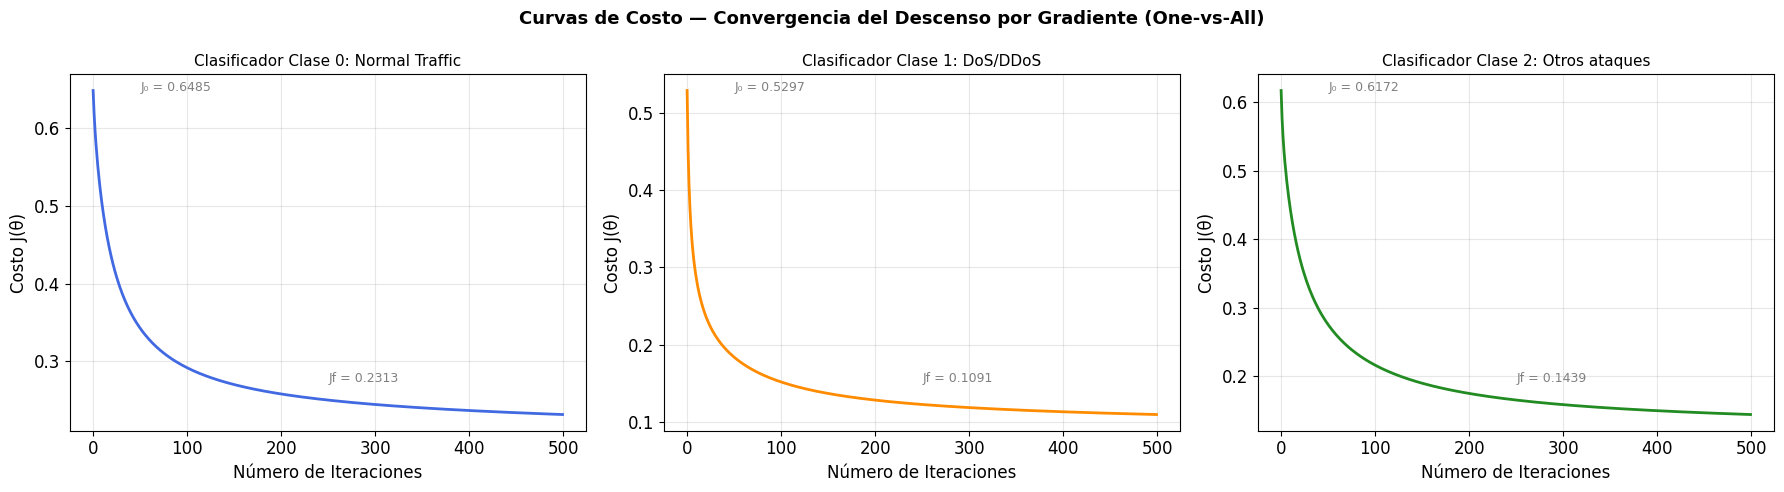

In [18]:
# ── Curvas individuales por clasificador ──
fig, axes = plt.subplots(1, NUM_CLASES, figsize=(18, 5))

for c in range(NUM_CLASES):
    iters = range(len(historiales[c]))
    axes[c].plot(iters, historiales[c], color=COLORES[c], lw=2)
    axes[c].set_title(f'Clasificador Clase {c}: {mapa_nombres[c]}', fontsize=11)
    axes[c].set_xlabel('Número de Iteraciones')
    axes[c].set_ylabel('Costo J(θ)')
    axes[c].grid(True, alpha=0.3)
    # Anotar valor inicial y final
    axes[c].annotate(f'J₀ = {historiales[c][0]:.4f}',
                     xy=(0, historiales[c][0]),
                     xytext=(NUM_ITERS*0.1, historiales[c][0]),
                     fontsize=9, color='gray')
    axes[c].annotate(f'Jf = {historiales[c][-1]:.4f}',
                     xy=(len(historiales[c])-1, historiales[c][-1]),
                     xytext=(NUM_ITERS*0.5, historiales[c][-1] + (historiales[c][0]-historiales[c][-1])*0.1),
                     fontsize=9, color='gray')

plt.suptitle('Curvas de Costo — Convergencia del Descenso por Gradiente (One-vs-All)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

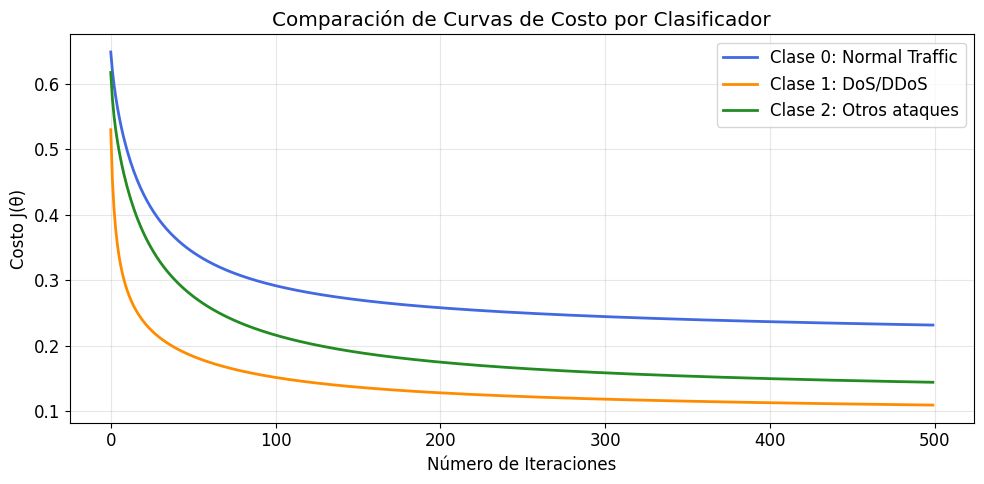

In [19]:
# ── Curvas superpuestas para comparación ──
fig, ax = plt.subplots(figsize=(10, 5))
for c in range(NUM_CLASES):
    ax.plot(range(len(historiales[c])), historiales[c],
            color=COLORES[c], lw=2, label=f'Clase {c}: {mapa_nombres[c]}')
ax.set_xlabel('Número de Iteraciones')
ax.set_ylabel('Costo J(θ)')
ax.set_title('Comparación de Curvas de Costo por Clasificador')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Predicción y Evaluación

### 7.1 Función de Predicción One-vs-All

Para predecir la clase de un nuevo ejemplo, calculamos la probabilidad de pertenencia a cada clase usando los K clasificadores entrenados. La clase predicha es aquella con la probabilidad más alta:

$$\hat{y} = \underset{k}{\arg\max} \; h_{\theta^{(k)}}(x) = \underset{k}{\arg\max} \; g(\theta^{(k)T} x)$$

In [20]:
def predictOneVsAll(all_theta, X):
    """
    Predice la clase de cada ejemplo en X usando el clasificador One-vs-All.

    Parámetros
    ----------
    all_theta : ndarray (K, n+1) — Parámetros entrenados (incluye bias)
    X         : ndarray (m, n)   — Datos de entrada (SIN columna de unos)

    Retorna
    -------
    predicciones   : ndarray (m,)    — Clase predicha {0, 1, 2}
    probabilidades : ndarray (m, K)  — Probabilidad por clase
    """
    m     = X.shape[0]
    X_aug = np.concatenate([np.ones((m, 1)), X], axis=1)  # Añadir columna de unos
    prob  = sigmoid(X_aug.dot(all_theta.T))                # Shape: (m, K)
    return np.argmax(prob, axis=1), prob

In [21]:
# Predicciones sobre entrenamiento y prueba
pred_train, prob_train = predictOneVsAll(all_theta, X_train)
pred_test,  prob_test  = predictOneVsAll(all_theta, X_test)

prec_train = np.mean(pred_train == y_train) * 100
prec_test  = np.mean(pred_test  == y_test)  * 100

print(f'Precisión global — Entrenamiento: {prec_train:.2f}%')
print(f'Precisión global — Prueba:        {prec_test:.2f}%')

Precisión global — Entrenamiento: 92.19%
Precisión global — Prueba:        92.26%


### 7.2 Matriz de Confusión

La matriz de confusión muestra el detalle de aciertos y errores por clase: las filas representan la clase real y las columnas la clase predicha. Los valores en la diagonal principal son predicciones correctas.

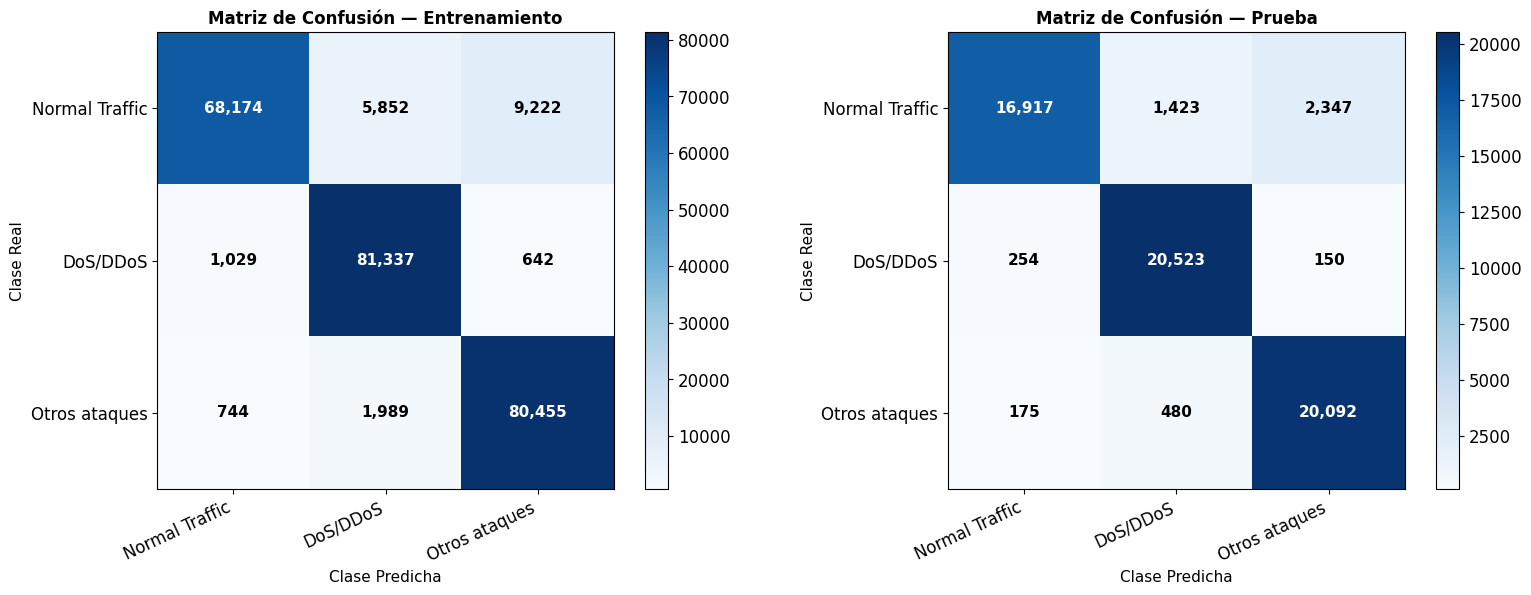

In [22]:
def matriz_confusion(y_real, y_pred, k):
    """Construye la matriz de confusión K×K sin sklearn."""
    mc = np.zeros((k, k), dtype=int)
    for r, p in zip(y_real.astype(int), y_pred.astype(int)):
        mc[r][p] += 1
    return mc

mc_test  = matriz_confusion(y_test,  pred_test,  NUM_CLASES)
mc_train = matriz_confusion(y_train, pred_train, NUM_CLASES)

# Visualizar matriz de confusión del conjunto de prueba
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mc, titulo in zip(axes, [mc_train, mc_test],
                           ['Entrenamiento', 'Prueba']):
    im = ax.imshow(mc, cmap='Blues')
    plt.colorbar(im, ax=ax)
    etiquetas = [mapa_nombres[c] for c in range(NUM_CLASES)]
    ax.set_xticks(range(NUM_CLASES)); ax.set_xticklabels(etiquetas, rotation=25, ha='right')
    ax.set_yticks(range(NUM_CLASES)); ax.set_yticklabels(etiquetas)
    for i in range(NUM_CLASES):
        for j in range(NUM_CLASES):
            color = 'white' if mc[i,j] > mc.max()/2 else 'black'
            ax.text(j, i, f'{mc[i,j]:,}', ha='center', va='center',
                    color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel('Clase Predicha', fontsize=11)
    ax.set_ylabel('Clase Real',     fontsize=11)
    ax.set_title(f'Matriz de Confusión — {titulo}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 7.3 Métricas por Clase

Calculamos las métricas de evaluación por clase:

- **Precisión (Precision)**: de todos los predichos como clase k, ¿cuántos realmente son clase k?
- **Sensibilidad (Recall)**: de todos los reales de clase k, ¿cuántos se predijeron correctamente?
- **F1-Score**: media armónica entre precision y recall

In [23]:
def metricas_por_clase(mc, nombres):
    """Calcula e imprime Precision, Recall y F1 por clase."""
    print(f"{'Clase':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Soporte':>10}")
    print('-' * 64)
    f1s, pesos = [], []
    for i, nom in enumerate(nombres):
        tp  = mc[i, i]
        fp  = mc[:, i].sum() - tp
        fn  = mc[i, :].sum() - tp
        sup = int(mc[i, :].sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append(f1); pesos.append(sup)
        print(f"{nom:<20} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {sup:>10,}")
    print('-' * 64)
    print(f"{'Macro avg':<20} {'':>10} {'':>10} {np.mean(f1s):>10.4f} {mc.sum():>10,}")
    print(f"{'Weighted avg':<20} {'':>10} {'':>10} {np.average(f1s, weights=pesos):>10.4f} {mc.sum():>10,}")

nombres_clases = [mapa_nombres[i] for i in range(NUM_CLASES)]

print('Métricas — Conjunto de Entrenamiento')
print('=' * 64)
metricas_por_clase(mc_train, nombres_clases)

print()
print('Métricas — Conjunto de Prueba')
print('=' * 64)
metricas_por_clase(mc_test, nombres_clases)

Métricas — Conjunto de Entrenamiento
Clase                 Precision     Recall   F1-Score    Soporte
----------------------------------------------------------------
Normal Traffic           0.9747     0.8189     0.8900     83,248
DoS/DDoS                 0.9121     0.9799     0.9448     83,008
Otros ataques            0.8908     0.9671     0.9274     83,188
----------------------------------------------------------------
Macro avg                                      0.9207    249,444
Weighted avg                                   0.9207    249,444

Métricas — Conjunto de Prueba
Clase                 Precision     Recall   F1-Score    Soporte
----------------------------------------------------------------
Normal Traffic           0.9753     0.8178     0.8896     20,687
DoS/DDoS                 0.9151     0.9807     0.9468     20,927
Otros ataques            0.8895     0.9684     0.9273     20,747
----------------------------------------------------------------
Macro avg             

## 8. Visualizaciones de Efectividad del Modelo

### 8.1 Evolución de la Precisión durante el Entrenamiento

Calculamos la precisión del clasificador en cada iteración, usando un subconjunto del conjunto de entrenamiento para observar cómo mejora con las iteraciones.

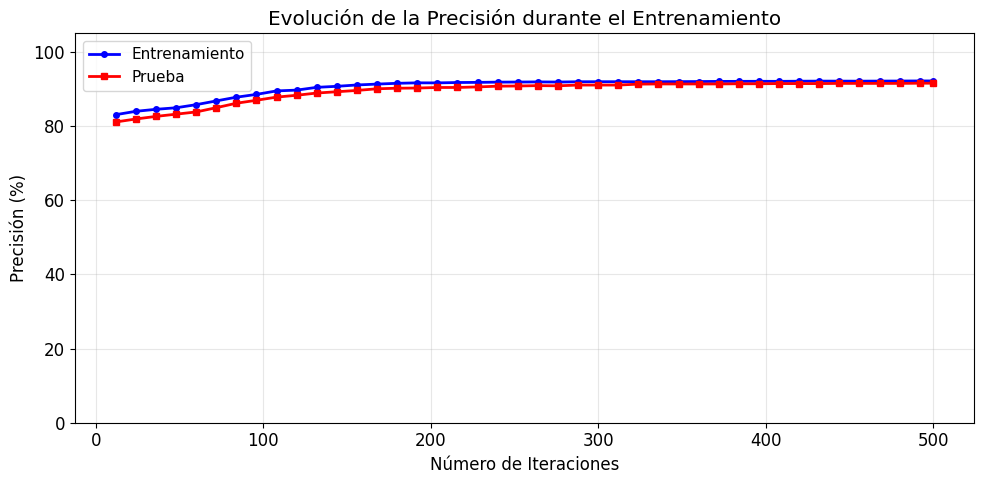

In [24]:
# Submuestras para calcular la gráfica de evolución más rápidamente
MC  = min(8_000, X_train.shape[0])
MTC = min(2_000, X_test.shape[0])

Xc   = X_train[:MC];   yc  = y_train[:MC]
Xtc  = X_test[:MTC];   ytc = y_test[:MTC]

Xc_aug  = np.concatenate([np.ones((MC,  1)), Xc],  axis=1)
Xtc_aug = np.concatenate([np.ones((MTC, 1)), Xtc], axis=1)

th_tmp = np.zeros((NUM_CLASES, Xc.shape[1] + 1))
cada   = max(1, NUM_ITERS // 40)    # ~40 puntos en la gráfica

tr_hist, te_hist, it_pts = [], [], []

for it in range(1, NUM_ITERS + 1):
    for c in range(NUM_CLASES):
        yb   = (yc == c).astype(float)
        h    = sigmoid(Xc_aug.dot(th_tmp[c]))
        grad = (1/MC) * Xc_aug.T.dot(h - yb)
        reg  = (LAMBDA_/MC) * th_tmp[c].copy(); reg[0] = 0
        th_tmp[c] -= ALPHA * (grad + reg)

    if it % cada == 0 or it == NUM_ITERS:
        pt = np.mean(np.argmax(sigmoid(Xc_aug.dot(th_tmp.T)),  axis=1) == yc)  * 100
        pe = np.mean(np.argmax(sigmoid(Xtc_aug.dot(th_tmp.T)), axis=1) == ytc) * 100
        tr_hist.append(pt); te_hist.append(pe); it_pts.append(it)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(it_pts, tr_hist, 'b-o', ms=4, lw=2, label='Entrenamiento')
ax.plot(it_pts, te_hist, 'r-s', ms=4, lw=2, label='Prueba')
ax.set_xlabel('Número de Iteraciones')
ax.set_ylabel('Precisión (%)')
ax.set_title('Evolución de la Precisión durante el Entrenamiento')
ax.legend(fontsize=11)
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Gráfica Comparativa: Precisión por Clase

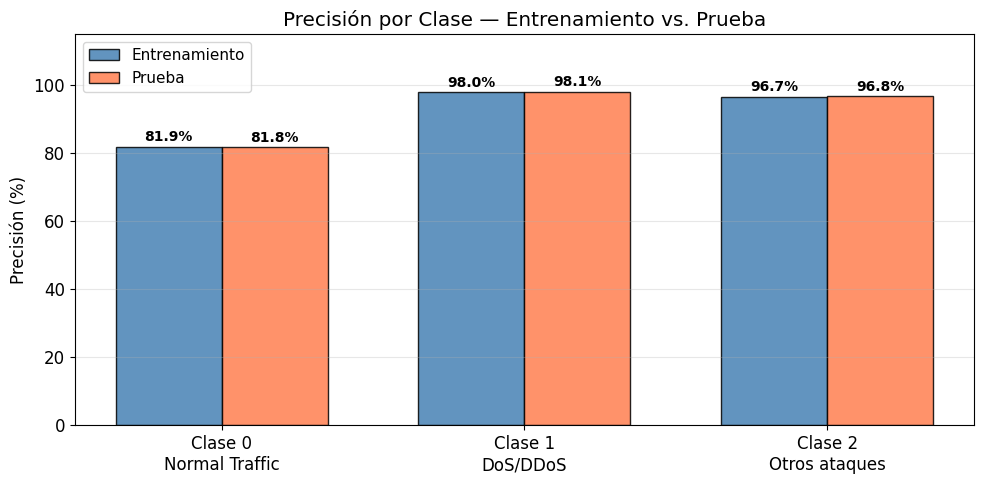

In [25]:
ptr = [np.mean(pred_train[y_train == c] == c) * 100 for c in range(NUM_CLASES)]
pte = [np.mean(pred_test[y_test   == c] == c) * 100 for c in range(NUM_CLASES)]

x, w = np.arange(NUM_CLASES), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, ptr, w, label='Entrenamiento',
            color='steelblue', edgecolor='black', alpha=0.85)
b2 = ax.bar(x + w/2, pte, w, label='Prueba',
            color='coral',     edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Clase {c}\n{mapa_nombres[c]}' for c in range(NUM_CLASES)])
ax.set_ylabel('Precisión (%)')
ax.set_title('Precisión por Clase — Entrenamiento vs. Prueba')
ax.legend(fontsize=11)
ax.set_ylim([0, 115])
ax.grid(True, alpha=0.3, axis='y')

for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.1f}%',
                xy=(b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 8.3 Distribución de Probabilidades Predichas

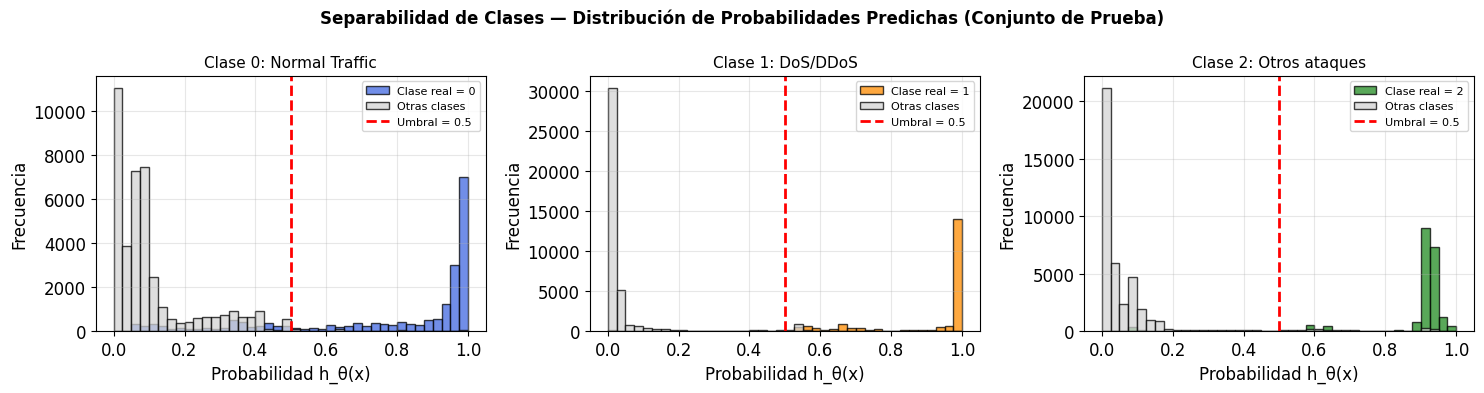

In [26]:
fig, axes = plt.subplots(1, NUM_CLASES, figsize=(15, 4))

for c in range(NUM_CLASES):
    pos = (y_test == c)
    neg = ~pos
    axes[c].hist(prob_test[pos, c], bins=40, color=COLORES[c],
                 alpha=0.75, edgecolor='black', label=f'Clase real = {c}')
    axes[c].hist(prob_test[neg, c], bins=40, color='lightgray',
                 alpha=0.75, edgecolor='black', label='Otras clases')
    axes[c].axvline(0.5, color='red', lw=2, linestyle='--', label='Umbral = 0.5')
    axes[c].set_title(f'Clase {c}: {mapa_nombres[c]}', fontsize=11)
    axes[c].set_xlabel('Probabilidad h_θ(x)')
    axes[c].set_ylabel('Frecuencia')
    axes[c].legend(fontsize=8)
    axes[c].grid(True, alpha=0.3)

plt.suptitle('Separabilidad de Clases — Distribución de Probabilidades Predichas (Conjunto de Prueba)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Resumen de Resultados

Presentamos un resumen completo del experimento.

In [27]:
print('=' * 70)
print('       RESUMEN — CLASIFICADOR ONE-VS-ALL — CICIDS2017')
print('=' * 70)
print(f'Dataset:                  CICIDS2017 Cleaned & Preprocessed')
print(f'Columna objetivo:         {COLUMNA_OBJETIVO}')
print(f'Características (n):      {X_train.shape[1]}  (≥ 40 ✓)')
print(f'Ejemplos totales (m):     {m_total:,}  (≥ 50,000 ✓)')
print(f'  └─ Entrenamiento (80%): {X_train.shape[0]:,}')
print(f'  └─ Prueba (20%):        {X_test.shape[0]:,}')
print()
print('Clases del modelo:')
for c, nom in mapa_nombres.items():
    print(f'  {c} → {nom}')
print()
print('Hiperparámetros:')
print(f'  Tasa de aprendizaje (α): {ALPHA}')
print(f'  Iteraciones:             {NUM_ITERS}')
print(f'  Regularización L2 (λ):   {LAMBDA_}')
print()
print('Resultados:')
print(f'  Precisión en entrenamiento: {prec_train:.2f}%')
print(f'  Precisión en prueba:        {prec_test:.2f}%')
print()
print('Costo final por clasificador:')
for c in range(NUM_CLASES):
    print(f'  Clase {c} ({mapa_nombres[c]:<18}): J_inicial = {historiales[c][0]:.6f}  →  J_final={historiales[c][-1]:.6f}')
print('=' * 70)

       RESUMEN — CLASIFICADOR ONE-VS-ALL — CICIDS2017
Dataset:                  CICIDS2017 Cleaned & Preprocessed
Columna objetivo:         Attack Type
Características (n):      52  (≥ 40 ✓)
Ejemplos totales (m):     311,805  (≥ 50,000 ✓)
  └─ Entrenamiento (80%): 249,444
  └─ Prueba (20%):        62,361

Clases del modelo:
  0 → Normal Traffic
  1 → DoS/DDoS
  2 → Otros ataques

Hiperparámetros:
  Tasa de aprendizaje (α): 0.1
  Iteraciones:             500
  Regularización L2 (λ):   0.1

Resultados:
  Precisión en entrenamiento: 92.19%
  Precisión en prueba:        92.26%

Costo final por clasificador:
  Clase 0 (Normal Traffic    ): J_inicial = 0.648479  →  J_final=0.231341
  Clase 1 (DoS/DDoS          ): J_inicial = 0.529750  →  J_final=0.109123
  Clase 2 (Otros ataques     ): J_inicial = 0.617206  →  J_final=0.143945
